In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('nhanes_cvd_females.csv')

In [4]:
df.head()

,SEQN,Age,Menopause_Status,Total_Cholesterol,LDL_Cholesterol
0,31131.0,44.0,Pre-menopausal,105.0,49.0
1,31151.0,59.0,Post-menopausal,205.0,104.0
2,31162.0,71.0,Post-menopausal,224.0,142.0
3,31187.0,22.0,Pre-menopausal,181.0,112.0
4,31437.0,59.0,Post-menopausal,215.0,127.0


In [5]:
df.describe()

,SEQN,Age,Total_Cholesterol,LDL_Cholesterol
count,848.000000,848.000000,848.000000,848.000000
mean,68595.939858,65.258255,188.920991,106.429245
std,20847.898444,13.688922,46.557092,40.340255
min,31131.000000,22.000000,93.000000,25.000000
25%,50438.250000,56.000000,158.000000,78.000000
50%,67636.000000,67.000000,182.500000,101.000000
75%,87735.500000,78.000000,214.000000,128.000000
max,102923.000000,85.000000,446.000000,354.000000


In [6]:
pre_meno = df[df['Menopause_Status'] == 'Pre-menopausal']
post_meno = df[df['Menopause_Status'] == 'Post-menopausal']

In [15]:
pre_meno.describe()

,SEQN,Age,Total_Cholesterol,LDL_Cholesterol
count,170.000000,170.000000,170.000000,170.000000
mean,67672.800000,52.623529,182.764706,102.388235
std,22213.293093,17.507041,40.151679,34.282189
min,31131.000000,22.000000,95.000000,35.000000
25%,48579.000000,40.000000,159.000000,79.000000
50%,65944.000000,47.000000,178.500000,96.500000
75%,89748.500000,69.500000,205.000000,123.000000
max,102923.000000,85.000000,308.000000,216.000000


In [16]:
post_meno.describe()

,SEQN,Age,Total_Cholesterol,LDL_Cholesterol
count,678.000000,678.000000,678.000000,678.000000
mean,68827.405605,68.426254,190.464602,107.442478
std,20502.001270,10.382337,47.932323,41.682865
min,31151.000000,35.000000,93.000000,25.000000
25%,51061.250000,61.000000,158.000000,77.000000
50%,68038.000000,70.000000,185.000000,102.000000
75%,87703.500000,79.000000,216.750000,129.750000
max,102729.000000,85.000000,446.000000,354.000000


In [7]:
avg_pre = pre_meno['LDL_Cholesterol'].mean()
avg_post = post_meno['LDL_Cholesterol'].mean()

In [8]:
print(avg_pre, avg_post)

102.38823529411765 107.4424778761062


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(pre, label='Pre-menopausal', fill=True)
sns.kdeplot(post, label='Post-menopausal', fill=True)
plt.xlabel('LDL Cholesterol')
plt.title('Distribution of LDL in Women with CVD')
plt.legend()
plt.show()

NameError: name 'pre' is not defined

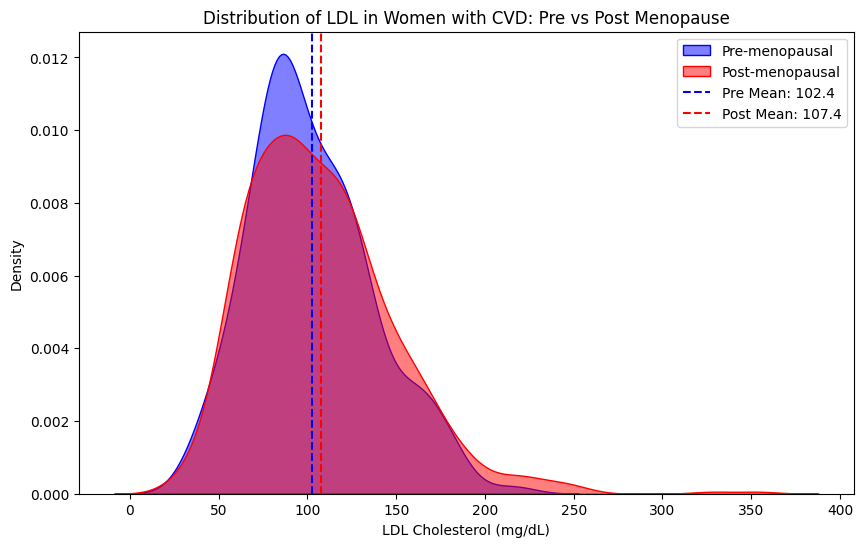

Statistical Significance (p-value): 0.1442


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load the data
df = pd.read_csv('nhanes_cvd_females.csv')

# 2. Define the groups (Fixes the NameError)
# We use .copy() to avoid SettingWithCopy warnings later
pre = df[df['Menopause_Status'] == 'Pre-menopausal']['LDL_Cholesterol'].dropna()
post = df[df['Menopause_Status'] == 'Post-menopausal']['LDL_Cholesterol'].dropna()

# 3. Create the Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(pre, label='Pre-menopausal', fill=True, color='blue', alpha=0.5)
sns.kdeplot(post, label='Post-menopausal', fill=True, color='red', alpha=0.5)

# Add lines for the Means (to visualize that 102 vs 107 gap)
plt.axvline(pre.mean(), color='blue', linestyle='--', label=f'Pre Mean: {pre.mean():.1f}')
plt.axvline(post.mean(), color='red', linestyle='--', label=f'Post Mean: {post.mean():.1f}')

plt.xlabel('LDL Cholesterol (mg/dL)')
plt.ylabel('Density')
plt.title('Distribution of LDL in Women with CVD: Pre vs Post Menopause')
plt.legend()
plt.show()

# 4. Statistical Check
t_stat, p_val = stats.ttest_ind(pre, post)
print(f"Statistical Significance (p-value): {p_val:.4f}")

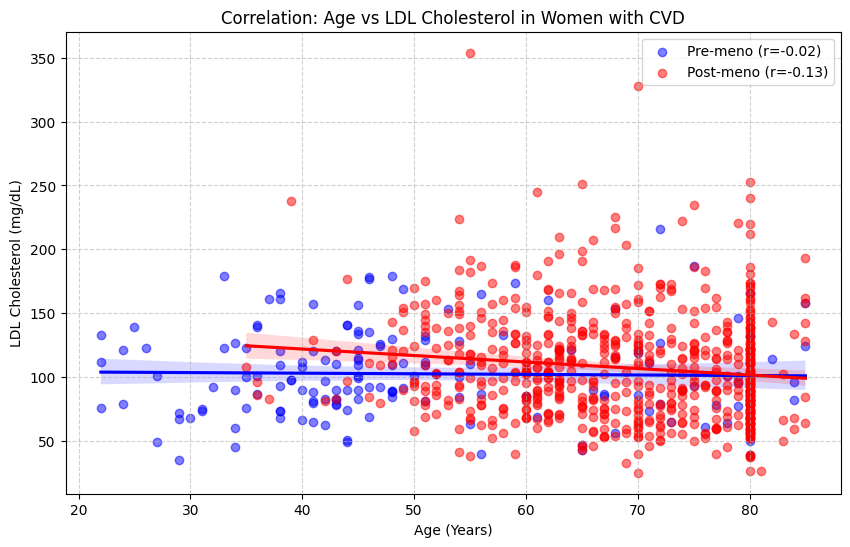

Correlation (r) for Pre-menopausal: -0.0237
Correlation (r) for Post-menopausal: -0.1267


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Load data
df = pd.read_csv('nhanes_cvd_females.csv').dropna(subset=['Age', 'LDL_Cholesterol'])

# 2. Separate data for R calculation
pre = df[df['Menopause_Status'] == 'Pre-menopausal']
post = df[df['Menopause_Status'] == 'Post-menopausal']

# 3. Calculate R coefficients
r_pre, _ = pearsonr(pre['Age'], pre['LDL_Cholesterol'])
r_post, _ = pearsonr(post['Age'], post['LDL_Cholesterol'])

# 4. Create the Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=pre, x='Age', y='LDL_Cholesterol', label=f'Pre-meno (r={r_pre:.2f})', color='blue', scatter_kws={'alpha':0.5})
sns.regplot(data=post, x='Age', y='LDL_Cholesterol', label=f'Post-meno (r={r_post:.2f})', color='red', scatter_kws={'alpha':0.5})

plt.title('Correlation: Age vs LDL Cholesterol in Women with CVD')
plt.xlabel('Age (Years)')
plt.ylabel('LDL Cholesterol (mg/dL)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Correlation (r) for Pre-menopausal: {r_pre:.4f}")
print(f"Correlation (r) for Post-menopausal: {r_post:.4f}")

/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_52813/2432241943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Menopause_Status', y='LDL_Cholesterol', data=df, inner="quartile", palette="muted")


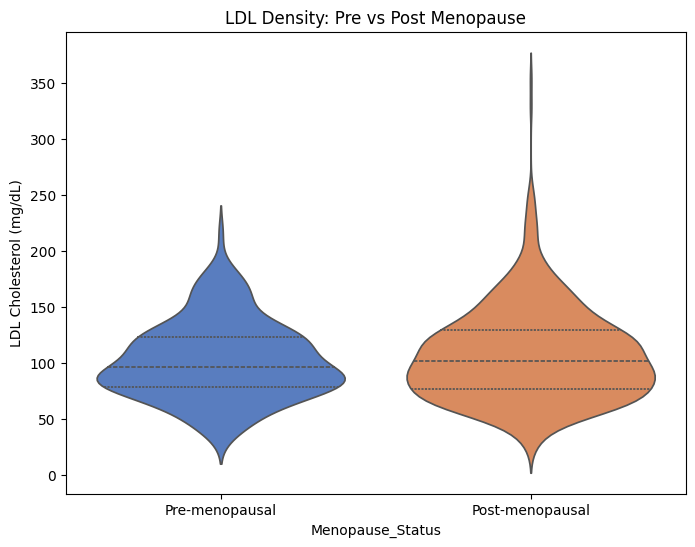

In [14]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Menopause_Status', y='LDL_Cholesterol', data=df, inner="quartile", palette="muted")
plt.title('LDL Density: Pre vs Post Menopause')
plt.ylabel('LDL Cholesterol (mg/dL)')
plt.show()

--- Summary Statistics ---
  Menopause_Status  CVD  count        mean        std
0  Post-menopausal   No   3589  120.568682  36.608631
1  Post-menopausal  Yes    678  107.442478  41.682865
2   Pre-menopausal   No   6297  103.113387  32.401226
3   Pre-menopausal  Yes    170  102.388235  34.282189


/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_52813/3742230278.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Menopause_Status', y='LDL_Cholesterol', palette='Set2', capsize=.1)


ValueError: Could not interpret value `CVD_Status` for `hue`. An entry with this name does not appear in `data`.

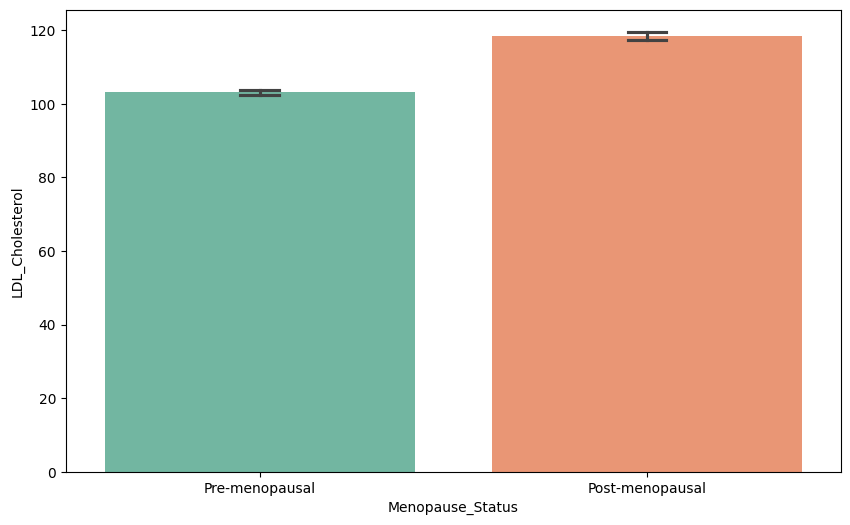

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Load your dataset
df = pd.read_csv('nhanes_cvd_females_disease_status.csv')

# 2. Grouped Summary Statistics
# This shows the mean LDL for: Pre-Healthy, Pre-CVD, Post-Healthy, Post-CVD
summary = df.groupby(['Menopause_Status', 'CVD'])['LDL_Cholesterol'].agg(['count', 'mean', 'std']).reset_index()
print("--- Summary Statistics ---")
print(summary)

# 3. Visualization: The Shield Gap Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Menopause_Status', y='LDL_Cholesterol', palette='Set2', capsize=.1)

# Overlay the individual points to see the distribution (optional but good for N check)
sns.stripplot(data=df, x='Menopause_Status', y='LDL_Cholesterol', hue='CVD_Status',
              dodge=True, alpha=0.3, palette='dark:black', legend=False)

plt.title('LDL Comparison: Testing the Estrogen Shield Hypothesis')
plt.ylabel('Mean LDL Cholesterol (mg/dL)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Statistical Analysis: Calculating the "Gap" Significance
def calculate_gap_stats(m_status):
    group = df[df['Menopause_Status'] == m_status]
    cvd = group[group['CVD'] == 'CVD']['LDL_Cholesterol'].dropna()
    healthy = group[group['CVD'] == 'Healthy']['LDL_Cholesterol'].dropna()

    t_stat, p_val = stats.ttest_ind(cvd, healthy)
    gap = cvd.mean() - healthy.mean()

    print(f"\nResults for {m_status}:")
    print(f"  LDL Gap (CVD minus Healthy): {gap:.2f} mg/dL")
    print(f"  P-value: {p_val:.4f}")

calculate_gap_stats('Pre-menopausal')
calculate_gap_stats('Post-menopausal')

In [26]:
df = pd.read_csv('nhanes_cvd_females_disease_status.csv')

In [28]:
# Wrap each condition in parentheses and use &
df_pre_dis = df[(df['Menopause_Status'] == 'Pre-menopausal') & (df['CVD'] == 'Yes')]

# To be safe, also create the 'No Disease' group for comparison
df_pre_no_dis = df[(df['Menopause_Status'] == 'Pre-menopausal') & (df['CVD'] == 'No')]

# Check your counts
print(f"Pre-menopausal with CVD: {len(df_pre_dis)}")
print(f"Pre-menopausal without CVD: {len(df_pre_no_dis)}")

Pre-menopausal with CVD: 170
Pre-menopausal without CVD: 6297


In [29]:
df_pre_dis.describe()

,SEQN,Age,Total_Cholesterol,LDL_Cholesterol
count,170.000000,170.000000,170.000000,170.000000
mean,67672.800000,52.623529,182.764706,102.388235
std,22213.293093,17.507041,40.151679,34.282189
min,31131.000000,22.000000,95.000000,35.000000
25%,48579.000000,40.000000,159.000000,79.000000
50%,65944.000000,47.000000,178.500000,96.500000
75%,89748.500000,69.500000,205.000000,123.000000
max,102923.000000,85.000000,308.000000,216.000000


In [30]:
df_pre_no_dis.describe()

,SEQN,Age,Total_Cholesterol,LDL_Cholesterol
count,6297.000000,6297.000000,6297.000000,6297.000000
mean,65645.385898,29.901858,179.492457,103.113387
std,20850.780141,13.649051,38.949451,32.401226
min,31133.000000,12.000000,69.000000,9.000000
25%,47633.000000,18.000000,153.000000,81.000000
50%,64597.000000,28.000000,174.000000,99.000000
75%,83260.000000,40.000000,201.000000,121.000000
max,102954.000000,85.000000,417.000000,344.000000


In [38]:
import pandas as pd

# 1. Define the "Case" group: Pre-menopausal women WITH CVD
df_pre_cvd = df[(df['Menopause_Status'] == 'Pre-menopausal') & (df['CVD'] == 'Yes')]

# 2. Define the "Control" pool: Pre-menopausal women WITHOUT CVD
# We filter them first, then take a random sample of 170
df_pre_no_cvd_pool = df[(df['Menopause_Status'] == 'Pre-menopausal') & (df['CVD'] == 'No')]

# 3. Create the random sample of 170
# random_state=42 ensures you get the same "random" sample every time you run it
df_pre_no_cvd_sample = df_pre_no_cvd_pool.sample(n=170, random_state=42)

# 4. Compare the means
mean_cvd = df_pre_cvd['LDL_Cholesterol'].mean()
mean_healthy = df_pre_no_cvd_sample['LDL_Cholesterol'].mean()

print(f"Pre-menopausal CVD (N={len(df_pre_cvd)}) LDL Mean: {mean_cvd:.2f}")
print(f"Pre-menopausal Healthy Sample (N=170) LDL Mean: {mean_healthy:.2f}")
print(f"Difference (The Shield-Breaker Gap): {mean_cvd - mean_healthy:.2f}")

# 5. Combine them for a specific plot if needed
df_comparison = pd.concat([df_pre_cvd, df_pre_no_cvd_sample])

Pre-menopausal CVD (N=170) LDL Mean: 102.39
Pre-menopausal Healthy Sample (N=170) LDL Mean: 106.06
Difference (The Shield-Breaker Gap): -3.68
